In [59]:
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import optparse
import pickle

import matplotlib.pyplot as plt

import sac.memory as mem
from sac.feedforward import Feedforward
# import SAC
from sac.DDPG import DDPGAgent
from sac.utils import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(1)

In [60]:
env_name = "Pendulum-v1"
env = gym.make(env_name)

In [61]:
render = False
log_interval = 20           # print avg reward in the interval
new_episodes = 40 # max training episodes
max_timesteps = 2000   
save_interval = 500

In [62]:
params = SB3_PARAMS
params["alpha"] = 0.1
params["entropy"] = -1
params["lr"] = 1e-4

In [63]:
random_seed = 0

In [64]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [65]:
hidden_sizes = [128, 128]
action_bounds = (env.action_space.low, env.action_space.high)
obs_dim = env.observation_space.shape[0]
sac = from_dict(hidden_sizes=hidden_sizes, obs_dim=obs_dim, action_bounds=action_bounds, **params)

In [66]:
agent = sac
agent_name = "SAC"

In [67]:
filepath = f"./results2/{agent_name}-{env_name}-{random_seed}"

In [68]:
warmup_agent(agent, env, 256, max_timesteps)

In [69]:
losses = []
rewards = []
lengths = []
i_episode = 0

In [70]:
losses, rewards, lengths, i_episode, alphas = train_agent(agent, env, i_episode, new_episodes, max_timesteps, filepath, losses, rewards, lengths, log_interval=1, save_interval=20, train_interval=1)

Episode 1 	 avg length: 200 	 reward: -1544.9155933213979
Episode 2 	 avg length: 200 	 reward: -1349.3457882601633
Episode 3 	 avg length: 200 	 reward: -1380.0812671862059
Episode 4 	 avg length: 200 	 reward: -890.3114666312404
Episode 5 	 avg length: 200 	 reward: -1128.7518822902518
Episode 6 	 avg length: 200 	 reward: -1500.0116791504881
Episode 7 	 avg length: 200 	 reward: -1348.0146657387227
Episode 8 	 avg length: 200 	 reward: -1233.7900037873794
Episode 9 	 avg length: 200 	 reward: -1035.1243087953987
Episode 10 	 avg length: 200 	 reward: -782.7290205161803
Episode 11 	 avg length: 200 	 reward: -774.1876252020546
Episode 12 	 avg length: 200 	 reward: -674.9717649300878
Episode 13 	 avg length: 200 	 reward: -639.2927003342402
Episode 14 	 avg length: 200 	 reward: -639.2754827740985
Episode 15 	 avg length: 200 	 reward: -895.6777763810193
Episode 16 	 avg length: 200 	 reward: -601.9038447321369
Episode 17 	 avg length: 200 	 reward: -712.0694320962375
Episode 18 	 av

In [ ]:
rewards, lengths, losses = load_stats(filepath) 

In [71]:
from sac.plots import *

In [72]:
plot_path = "plots3"

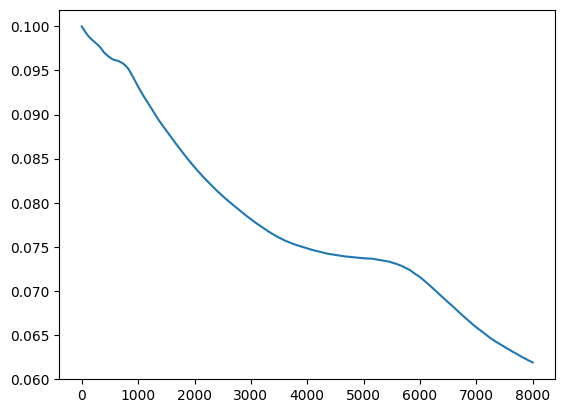

In [73]:
plt.plot(alphas)
plt.savefig(f"plots3/alphas_0.1_1_4.png")

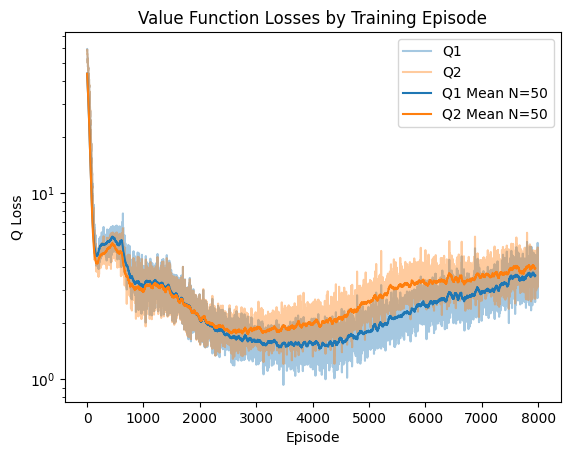

In [74]:
q_losses = np.asarray(losses)[:,:2]
plot_q(q_losses, plot_path)

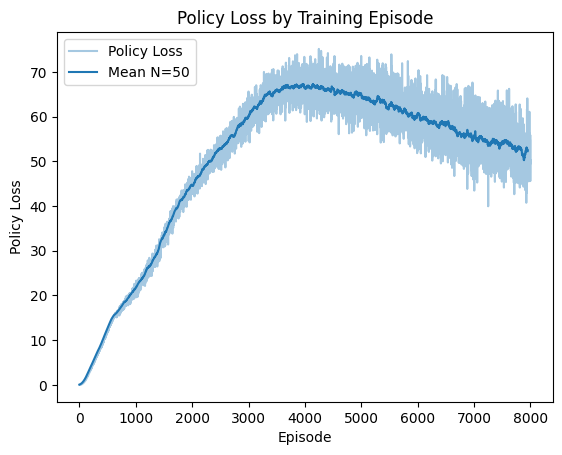

In [75]:
policy_loss = np.asarray(losses)[:,2]
plot_policy_loss(policy_loss, plot_path)

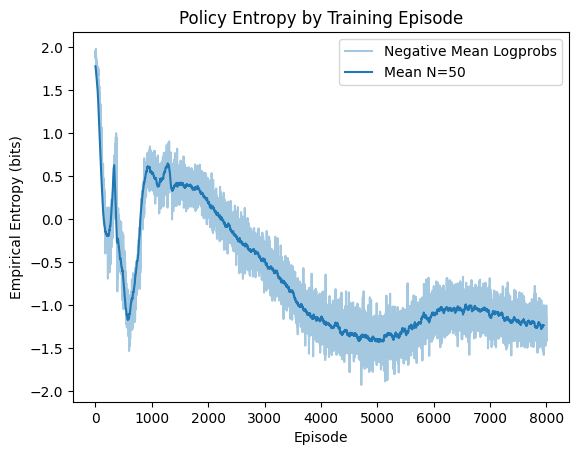

In [76]:
logprobs = np.asarray(losses)[:,-1]
plot_entropy(logprobs, plot_path)

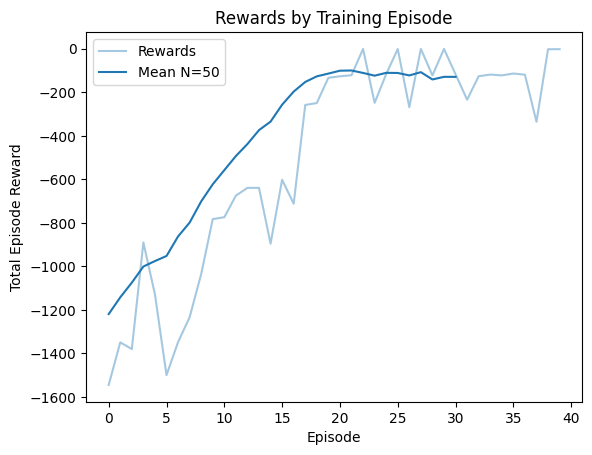

In [77]:
plot_rewards(rewards, plot_path, 10)